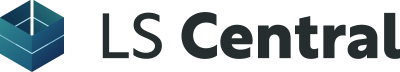

# **Fabric Notebook and Power BI Integration** 
###### This notebook demonstrates how to use Microsoft Fabric Notebooks to interact with [**Analytics for LS Central**](https://help.lscentral.lsretail.com/Content/Analytics/Analytics.htm?tocpath=LS%C2%A0Central%20Modules%7CAnalytics%7C_____0) Power BI semantic models, retrieve data, and visualize it.
###### It provides step-by-step examples of connecting to Power BI datasets, running DAX queries, and visualizing results, showcasing the convenience and flexibility of Fabric Notebooks for business analytics and reporting.



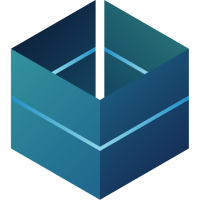
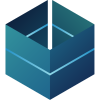
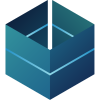

## Overview
 
 ###### Fabric Notebooks allow you to:
 ###### - Connect directly to Power BI semantic models (datasets)
 ###### - Retrieve and explore metadata (reports, datasets, tables, measures)
 ###### - Run DAX queries for custom analytics
 ###### - Visualize data interactively using Python libraries
###### 
###### 
 ###### This notebook is tailored for LS Central analytics, but the approach is applicable to any Power BI semantic model.

## 📊 Step 1: Discover Available Power BI Reports
##### 
##### Let's start by connecting to our Power BI environment and listing all available reports. This helps us see what analytics content we can explore!

In [1]:
# Retrieve data and metadata from Semantic Models 
import sempy.fabric as fabric

# Retrieve Reports list 
df_reports = fabric.list_reports()
display(df_reports)

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 3, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, cbe2b919-6c0b-4cc4-a722-752d4d43d5e3)


 ## 📑 Step 2: Select and Display a Power BI Report
 
##### Now, we'll choose a specific report from our list and display it right here in the notebook. This makes it easy to interact with your business data without leaving this environment!


In [2]:
from powerbiclient import Report

# Retrieve group ID and report ID from report link; 
# https://app.powerbi.com/groups/494503b4-71ef-442b-8979-b3d33bfbf3f7/reports/5903637e-618c-47f7-b78c-6376ea38e292/07237ef05b6054d6d689?experience=power-bi

group_id = "494503b4-71ef-442b-8979-b3d33bfbf3f7"
report_id = "5903637e-618c-47f7-b78c-6376ea38e292"

report = Report(group_id=group_id, report_id=report_id, embed=True)
display(report)


StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 4, Finished, Available, Finished)

Report()

## 📦 Step 3: Explore Available Datasets
##### 
##### Next, let's see which datasets are available for analysis. Datasets are collections of business data that we can use for reporting and insights.


In [3]:
df_datasets = fabric.list_datasets()
display(df_datasets)

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 5, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, edf47541-dae5-46b9-ae50-5e30c0e0d0c3)

 ## 🗂️ Step 4: Dive Into Tables
 
 ##### We'll now look at the tables inside our chosen dataset. Tables organize your business data into meaningful categories.

In [4]:
df_tables = fabric.list_tables("Finance")

display(df_tables)

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 6, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, e2f79f5b-26b1-4bee-9a35-d6a0c3d1a984)

## 📏 Step 5: Discover Measures

 ##### Measures are calculations (like totals or averages) that help us analyze our data. Let's list all available measures in the Finance dataset.

In [5]:
df_measures = fabric.list_measures("Finance")

display(df_measures)

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 7, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 43b10690-9cfc-4024-85b5-76313fac3701)

 ## 📋 Step 6: View Table Data
 
##### Let's take a closer look at the actual data inside the "G/L Entries" table. This gives us a detailed view of business transactions.

In [6]:
df_table = fabric.read_table("Finance", "G/L Entries")

display(df_table)

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 8, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, c2376e85-e483-460a-9864-f14e392eb8c1)

## 🌍 Step 7: Prepare Data for Visualization

 ##### Before visualizing, we'll make sure our data is in the right format and ready for analysis. This step ensures everything looks great in our charts!

In [7]:
# Import loacal language setting for report building 
import locale
locale.setlocale(locale.LC_TIME, "en_US.UTF-8")  # Use "en_US" or another as available on your system

import pandas as pd
from powerbiclient import QuickVisualize, get_dataset_config

# Read the table from Lakehouse
df_table = fabric.read_table("Finance", "G/L Entries")

# This avoids dropping all rows and keeps the dataset intact
if df_table['Closing Entry'].dtype == 'boolean':
    df_table['Closing Entry'] = df_table['Closing Entry'].astype(float)

# Set display options (optional)
pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)

# Create a Power BI report object from the cleaned data
PBI_visualize = QuickVisualize(get_dataset_config(df_table))

# Render the report
PBI_visualize


StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 9, Finished, Available, Finished)

QuickVisualize()

 ## 🧮 Step 8: Run a Custom Analysis with DAX

 ##### We'll use a special language called DAX to calculate revenue by fiscal year and month. This helps us uncover trends and patterns in your business!

In [8]:
# Run the DAX query to get Fiscal Year, Fiscal Month, and Revenue
df_dax = fabric.evaluate_dax(
    "Finance",
    """
    EVALUATE
    SUMMARIZECOLUMNS(
        'Date'[Fiscal Year] ,
        'Date'[Fiscal Month] ,
        "Revenue", CALCULATE([Revenue] )
    )
    """
)

# Ensure Revenue is numeric
import pandas as pd
df_dax['[Revenue]'] = pd.to_numeric(df_dax['[Revenue]'], errors='coerce')

# Display the DataFrame to verify
display(df_dax)


StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 10, Finished, Available, Finished)

2025-09-24 11:05:33.834: '[Revenue]' ('System.Object'/'Object') is serialized as string. To improve performance cast to desired type.


SynapseWidget(Synapse.DataFrame, 1422846e-7e3d-4a18-92b6-3ce70116c9ef)

## 🔄 Step 9: Prepare Data for Advanced Analytics

 ##### We'll convert our results into a format that allows us to use even more powerful analytics tools, like SQL queries.

In [13]:
# If df_dax is a pandas DataFrame:
spark_df = spark.createDataFrame(df_dax)

# Register as a temp view for SQL
spark_df.createOrReplaceTempView("df_dax")

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 15, Finished, Available, Finished)

## 📝 Step 10: (Optional) Query Data with SQL

##### If you like, you can use SQL to ask questions about your data—just like a data scientist!


In [19]:
%%sql
SELECT *
FROM df_dax

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 21, Finished, Available, Finished)

<Spark SQL result set with 16 rows and 3 fields>

## 📈 Step 11: Visualize Revenue Trends
##### 
 ##### Finally, let's create a beautiful chart to show how revenue changes month by month. Visualizations make it easy to spot trends and make informed decisions!

StatementMeta(, dd4c1bee-1445-468c-8e86-d5522e93ddcc, 14, Finished, Available, Finished)

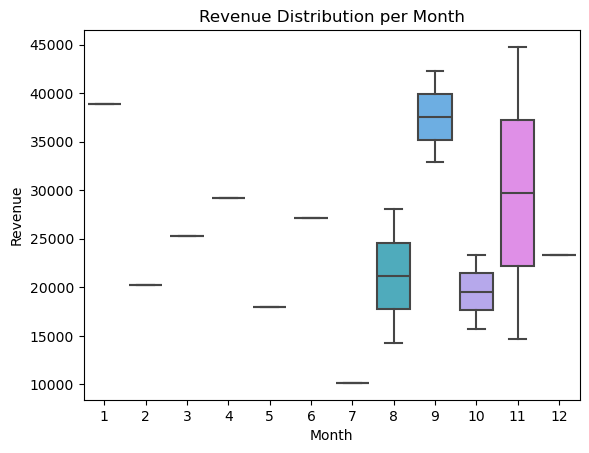

In [12]:
# View the distribution of tips by day of week using Seaborn
import matplotlib.pyplot as plt
import seaborn as sns
ax = sns.boxplot(x="Date[Fiscal Month]", y="[Revenue]",data=df_dax, showfliers = False)
ax.set_title('Revenue Distribution per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.show()

 ## 🎉 End
 ##### With just a few steps, we've connected to Power BI, explored business data, performed custom analysis, and visualized insights—all in one place! Fabric Notebooks make business analytics easy, interactive, and accessible for everyone.

# **Conclusion**

##### This notebook illustrates the power and convenience of using Fabric Notebooks for business analytics:
##### - Seamless integration with Power BI semantic models
##### - Flexible data exploration and visualization
##### - Ability to run custom DAX queries and advanced analytics
##### 
##### **Fabric Notebooks empower business users and analysts to quickly gain insights from their Power BI data, all within a familiar Python environment.**